# Australia Weather Data

1. Import packages
2. Load dataset
3. Preprocess data
4. Analyze data
5. Aggregate and join data
6. Feature selection: check correlation of features

## 1. Import packages

In [1]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

## 2. Load dataset

In [3]:
df_weather = pd.read_csv('../data/Weather Training Data.csv')

In [4]:
print(df_weather.shape)
print(df_weather.info())

(99516, 23)
<class 'pandas.DataFrame'>
RangeIndex: 99516 entries, 0 to 99515
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   row ID         99516 non-null  str    
 1   Location       99516 non-null  str    
 2   MinTemp        99073 non-null  float64
 3   MaxTemp        99286 non-null  float64
 4   Rainfall       98537 non-null  float64
 5   Evaporation    56985 non-null  float64
 6   Sunshine       52199 non-null  float64
 7   WindGustDir    92995 non-null  str    
 8   WindGustSpeed  93036 non-null  float64
 9   WindDir9am     92510 non-null  str    
 10  WindDir3pm     96868 non-null  str    
 11  WindSpeed9am   98581 non-null  float64
 12  WindSpeed3pm   97681 non-null  float64
 13  Humidity9am    98283 non-null  float64
 14  Humidity3pm    97010 non-null  float64
 15  Pressure9am    89768 non-null  float64
 16  Pressure3pm    89780 non-null  float64
 17  Cloud9am       61944 non-null  float64
 18  Cloud

In [5]:
print(df_weather.isnull().sum())

row ID               0
Location             0
MinTemp            443
MaxTemp            230
Rainfall           979
Evaporation      42531
Sunshine         47317
WindGustDir       6521
WindGustSpeed     6480
WindDir9am        7006
WindDir3pm        2648
WindSpeed9am       935
WindSpeed3pm      1835
Humidity9am       1233
Humidity3pm       2506
Pressure9am       9748
Pressure3pm       9736
Cloud9am         37572
Cloud3pm         40002
Temp9am            614
Temp3pm           1904
RainToday          979
RainTomorrow         0
dtype: int64


## 3. Preprocess data

In [6]:
list_col_numerical = ['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation',
                         'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm',
                         'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm',
                         'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm']

list_col_categorical = ['WindGustDir', 'WindDir9am', 'WindDir3pm']


In [7]:
df_missing_pct = df_weather[list_col_numerical].isna().mean().sort_values(ascending=False) * 100
df_missing_pct

Sunshine         47.547128
Evaporation      42.737851
Cloud3pm         40.196551
Cloud9am         37.754733
Pressure9am       9.795410
Pressure3pm       9.783351
WindGustSpeed     6.511516
Humidity3pm       2.518188
Temp3pm           1.913260
WindSpeed3pm      1.843925
Humidity9am       1.238997
Rainfall          0.983761
WindSpeed9am      0.939547
Temp9am           0.616986
MinTemp           0.445155
MaxTemp           0.231119
dtype: float64

More than 30% of data missing: `Sunshine`, `Evaporation`, `Cloud3pm`, `Cloud9am`

Mean imputation
- May hurt 49-row dataset if done blindly
- If a feature is missing for a large share of a city's rows (or even entirely missing for some cities), imputing it isn't filling in noise around a real signal-- it's inventing most of that column's information.
- In that case, dropping the feature is more honest than imputing it, especially since feature set is already deliberately narrow

In [8]:
df_weather_imputed_global = df_weather.copy()

# Mean imputation for numerical variables
df_weather_imputed_global[list_col_numerical] = df_weather_imputed_global[list_col_numerical].fillna(df_weather_imputed_global[list_col_numerical].mean())

# Mode imputation for categorical variables
for col in list_col_categorical:
    df_weather_imputed_global[col] = df_weather_imputed_global[col].fillna(df_weather_imputed_global[col].value_counts().idxmax())

Impute at the right level: per-city, not global

- Impute individual missing daily readings using that city's own mean, before aggregating -- not the global mean across all of Australia.
- When we impute a global mean before aggregating, we're quietly pulling every city's statistics toward the country-wide average, which flattens exactly the city-to-city variation our model is trying to learn from -- a real risk with only 49 rows to begin with.
- Global mean imputation should only be a fallback for the rare case where a city has zero non-null values for that variable (nothing city-specific to average from)

For Locations with zero non-null values in one or more numerical variables, we suggest dropping the Location rather than using global mean imputation.

Filter to Locations with no fully missing features

In [9]:
df_missing_pct = df_weather.groupby('Location')[list_col_numerical].apply(lambda x: x.isna().mean() * 100).T
df_missing_pct = df_missing_pct.T
df_no_fully_missing_feat = df_missing_pct[~((df_missing_pct == 100).any(axis=1))].reset_index()

In [10]:
df_weather_filtered = df_weather[df_weather['Location'].isin(df_no_fully_missing_feat['Location'])].reset_index(drop=True)
df_weather_filtered.head()

,row ID,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,Row4262,Cobar,17.9,35.2,0.0,12.0,12.3,SSW,48.0,ENE,...,20.0,13.0,1006.3,1004.4,2.0,5.0,26.6,33.4,No,0
1,Row4263,Cobar,15.5,34.1,0.0,12.6,13.3,SE,30.0,NaN,...,NaN,7.0,NaN,1011.6,NaN,1.0,NaN,32.7,No,0
2,Row4264,Cobar,27.1,36.1,0.0,13.0,0.0,N,43.0,N,...,26.0,19.0,1007.7,1007.4,8.0,8.0,30.7,34.3,No,0
3,Row4265,Cobar,23.3,34.0,0.0,9.8,12.6,SSW,41.0,S,...,33.0,15.0,1011.3,1009.9,3.0,1.0,25.0,31.5,No,0
4,Row4266,Cobar,16.1,34.2,0.0,14.6,13.2,SE,37.0,SE,...,25.0,9.0,1013.3,1009.2,1.0,1.0,20.7,32.8,No,0


In [11]:
def impute_features(df_weather, list_feat_cols, str_city_col='Location'):
    df = df_weather.copy()
    for col in list_feat_cols:
        # Fill with each city's own mean first
        df[col] = df.groupby(str_city_col)[col].transform(lambda s: s.fillna(s.mean()))

        # Fallback: global mean, only for cities with zero non-null values for this column
        if df[col].isna().any():
            n_fallback = df[col].isna().sum()
            print(f"  {col}: {n_fallback} rows had no city-level data — using global mean as fallback")
            df[col] = df[col].fillna(df[col].mean())
    return df

In [12]:
impute_features(df_weather, list_col_numerical)

  Evaporation: 30968 rows had no city-level data — using global mean as fallback
  Sunshine: 36322 rows had no city-level data — using global mean as fallback
  WindGustSpeed: 4147 rows had no city-level data — using global mean as fallback
  Pressure9am: 8211 rows had no city-level data — using global mean as fallback
  Pressure3pm: 8211 rows had no city-level data — using global mean as fallback
  Cloud9am: 23770 rows had no city-level data — using global mean as fallback
  Cloud3pm: 23770 rows had no city-level data — using global mean as fallback


,row ID,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,Row0,Albury,13.4,22.9,0.6,5.434098,7.647679,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.000000,5.476000,16.9,21.8,No,0
1,Row1,Albury,7.4,25.1,0.0,5.434098,7.647679,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,6.417749,5.476000,17.2,24.3,No,0
2,Row2,Albury,17.5,32.3,1.0,5.434098,7.647679,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.000000,8.000000,17.8,29.7,No,0
3,Row3,Albury,14.6,29.7,0.2,5.434098,7.647679,WNW,56.0,W,...,55.0,23.0,1009.2,1005.4,6.417749,5.476000,20.6,28.9,No,0
4,Row4,Albury,7.7,26.7,0.0,5.434098,7.647679,W,35.0,SSE,...,48.0,19.0,1013.4,1010.1,6.417749,5.476000,16.3,25.5,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99511,Row101816,Uluru,8.0,20.7,0.0,5.434098,7.647679,ESE,41.0,SE,...,56.0,32.0,1028.1,1024.3,5.660550,7.000000,11.6,20.0,No,0
99512,Row101817,Uluru,3.5,21.8,0.0,5.434098,7.647679,E,31.0,ESE,...,59.0,27.0,1024.7,1021.2,5.660550,4.847015,9.4,20.9,No,0
99513,Row101818,Uluru,2.8,23.4,0.0,5.434098,7.647679,E,31.0,SE,...,51.0,24.0,1024.6,1020.3,5.660550,4.847015,10.1,22.4,No,0
99514,Row101819,Uluru,3.6,25.3,0.0,5.434098,7.647679,NNW,22.0,SE,...,56.0,21.0,1023.5,1019.1,5.660550,4.847015,10.9,24.5,No,0


In [13]:
df_weather_imputed = impute_features(df_weather_filtered, list_col_numerical)

In [14]:
df_weather_imputed.Location.nunique()

26

In [18]:
list_col_numerical_2 = ['Rainfall',# 'Evaporation',
                         'Sunshine',
                         'Humidity3pm', #'Pressure9am', 'Pressure3pm','Humidity9am', 
                         'Cloud9am', 'Cloud3pm', 'MaxTemp']

df_missing_pct_2 = df_weather.groupby('Location')[list_col_numerical_2].apply(lambda x: x.isna().mean() * 100).T
df_missing_pct_2 = df_missing_pct_2.T
df_no_fully_missing_feat_2 = df_missing_pct_2[~((df_missing_pct_2 == 100).any(axis=1))].reset_index()

df_weather_filtered_2 = df_weather[df_weather['Location'].isin(df_no_fully_missing_feat_2['Location'])].reset_index(drop=True)
df_weather_filtered_2.head()

,row ID,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,Row4262,Cobar,17.9,35.2,0.0,12.0,12.3,SSW,48.0,ENE,...,20.0,13.0,1006.3,1004.4,2.0,5.0,26.6,33.4,No,0
1,Row4263,Cobar,15.5,34.1,0.0,12.6,13.3,SE,30.0,NaN,...,NaN,7.0,NaN,1011.6,NaN,1.0,NaN,32.7,No,0
2,Row4264,Cobar,27.1,36.1,0.0,13.0,0.0,N,43.0,N,...,26.0,19.0,1007.7,1007.4,8.0,8.0,30.7,34.3,No,0
3,Row4265,Cobar,23.3,34.0,0.0,9.8,12.6,SSW,41.0,S,...,33.0,15.0,1011.3,1009.9,3.0,1.0,25.0,31.5,No,0
4,Row4266,Cobar,16.1,34.2,0.0,14.6,13.2,SE,37.0,SE,...,25.0,9.0,1013.3,1009.2,1.0,1.0,20.7,32.8,No,0


In [19]:
df_weather_imputed_2 = impute_features(df_weather_filtered_2, list_col_numerical)

  Evaporation: 1953 rows had no city-level data — using global mean as fallback
  WindGustSpeed: 2051 rows had no city-level data — using global mean as fallback


In [20]:
df_weather_imputed_2.Location.nunique()

28

## 4. Analyze data

In [14]:
def plot_feature(df_orig, str_feat):
    df = df_orig.copy()
    df = df.groupby(['Location'])[[str_feat]].mean()
    df = df.reset_index()
    x = df.loc[:, 'Location']
    y = df[str_feat] 

    plt.figure()

    plt.bar(x, y, label = str_feat)

    plt.xlabel('Location')
    plt.ylabel(str_feat)
    plt.title(f'Location-wise observation of Average {str_feat}')
    plt.legend(loc = 'best')
    plt.xticks(rotation=80)
    plt.show()

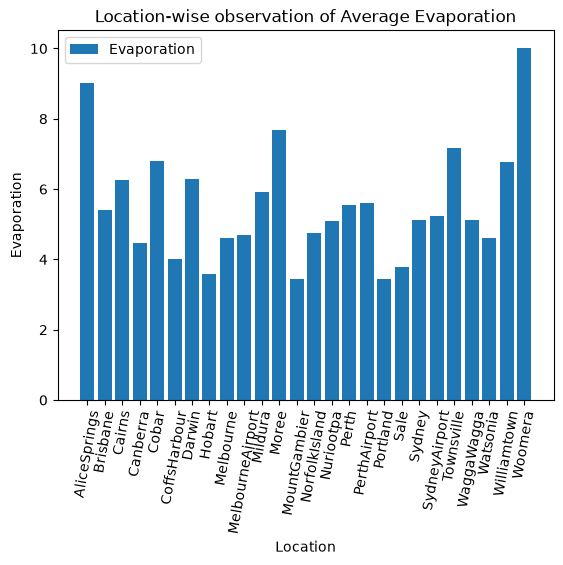

In [15]:
plot_feature(df_weather_imputed, 'Evaporation')

### 4.1. Average WindSpeed Analysis

In [16]:
df_windspeed = df_weather_imputed.groupby(['Location'])[['WindSpeed9am', 'WindSpeed3pm']].mean()
df_windspeed = df_windspeed.reset_index()
df_windspeed.head()

,Location,WindSpeed9am,WindSpeed3pm
0,AliceSprings,14.659112,18.018886
1,Brisbane,6.990917,10.955475
2,Cairns,15.966683,21.949048
3,Canberra,10.437360,19.101703
4,Cobar,14.595192,15.023044


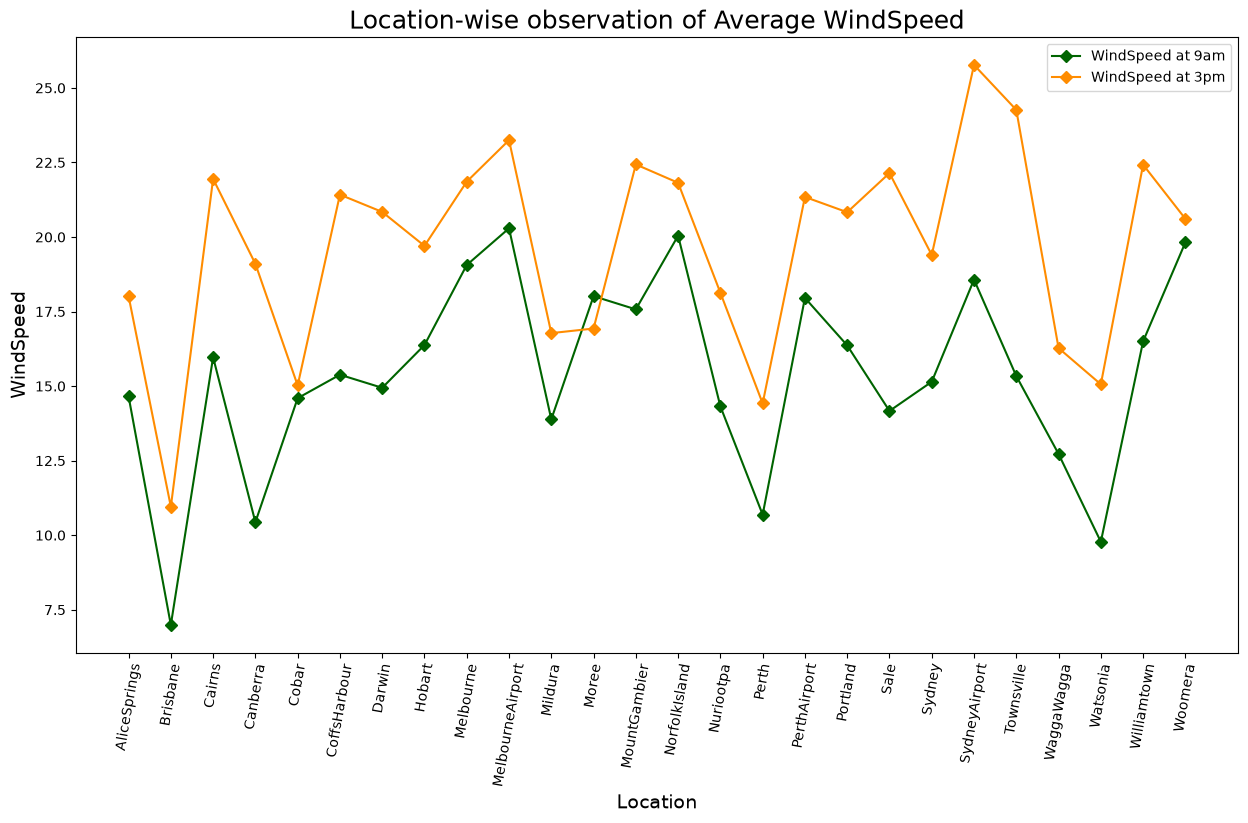

In [17]:
x = df_windspeed.loc[:, 'Location']
y1 = df_windspeed['WindSpeed9am'] 
y2 = df_windspeed['WindSpeed3pm']

plt.figure(figsize = (15, 8))

plt.plot(x, y1, marker='D', color = 'darkgreen', label = 'WindSpeed at 9am') 
plt.plot(x, y2, marker='D', color = 'darkorange', label = 'WindSpeed at 3pm')

plt.xlabel('Location', fontsize = 14)
plt.ylabel('WindSpeed', fontsize = 14)
plt.title('Location-wise observation of Average WindSpeed', fontsize = 18)
plt.legend(fontsize = 10, loc = 'best')
plt.xticks(rotation=80)
plt.show()

### 4.2 Average Humidity Analysis

In [18]:
df_humidity = df_weather_imputed.groupby(['Location'])[['Humidity9am', 'Humidity3pm']].mean()
df_humidity = df_humidity.reset_index()
df_humidity.head()

,Location,Humidity9am,Humidity3pm
0,AliceSprings,39.834121,24.253901
1,Brisbane,63.857338,53.660438
2,Cairns,69.971918,61.711566
3,Canberra,73.111537,45.634075
4,Cobar,54.891153,33.624441


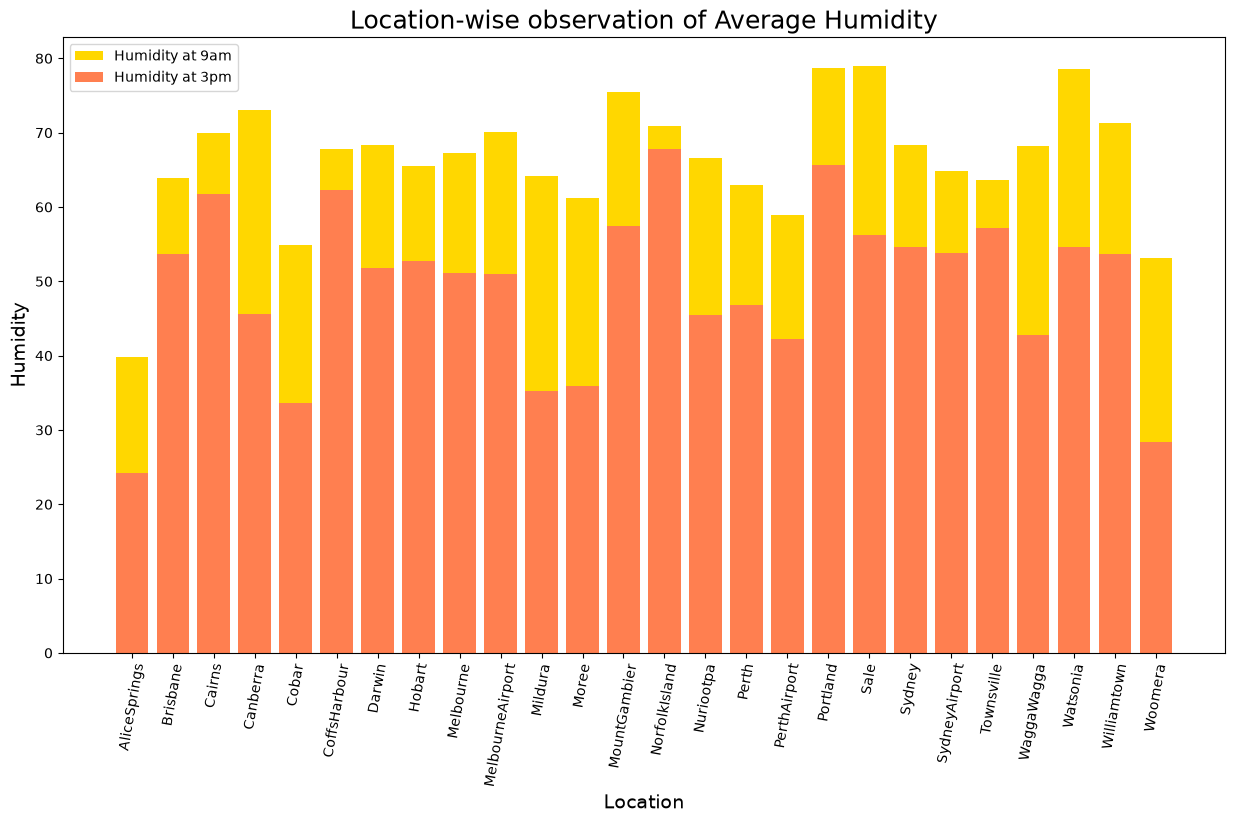

In [19]:
x = df_humidity.loc[:, 'Location']
y1 = df_humidity['Humidity9am'] 
y2 = df_humidity['Humidity3pm']

plt.figure(figsize = (15, 8))

plt.bar(x, y1, color = 'gold', label = 'Humidity at 9am') 
plt.bar(x, y2, color = 'coral',label = 'Humidity at 3pm')

plt.xlabel('Location', fontsize = 14)
plt.ylabel('Humidity', fontsize = 14)
plt.title('Location-wise observation of Average Humidity', fontsize = 18)
plt.legend(fontsize = 10, loc = 'best')
plt.xticks(rotation=80)
plt.show()

### 4.3 Average Pressure Analysis

In [20]:
df_pressure = df_weather_imputed.groupby(['Location'])[['Pressure9am', 'Pressure3pm']].mean()
df_pressure = df_pressure.reset_index()
df_pressure.head()

,Location,Pressure9am,Pressure3pm
0,AliceSprings,1016.610104,1012.804487
1,Brisbane,1018.289373,1015.144389
2,Cairns,1014.122180,1011.070062
3,Canberra,1019.018837,1016.271793
4,Cobar,1017.904875,1015.240232


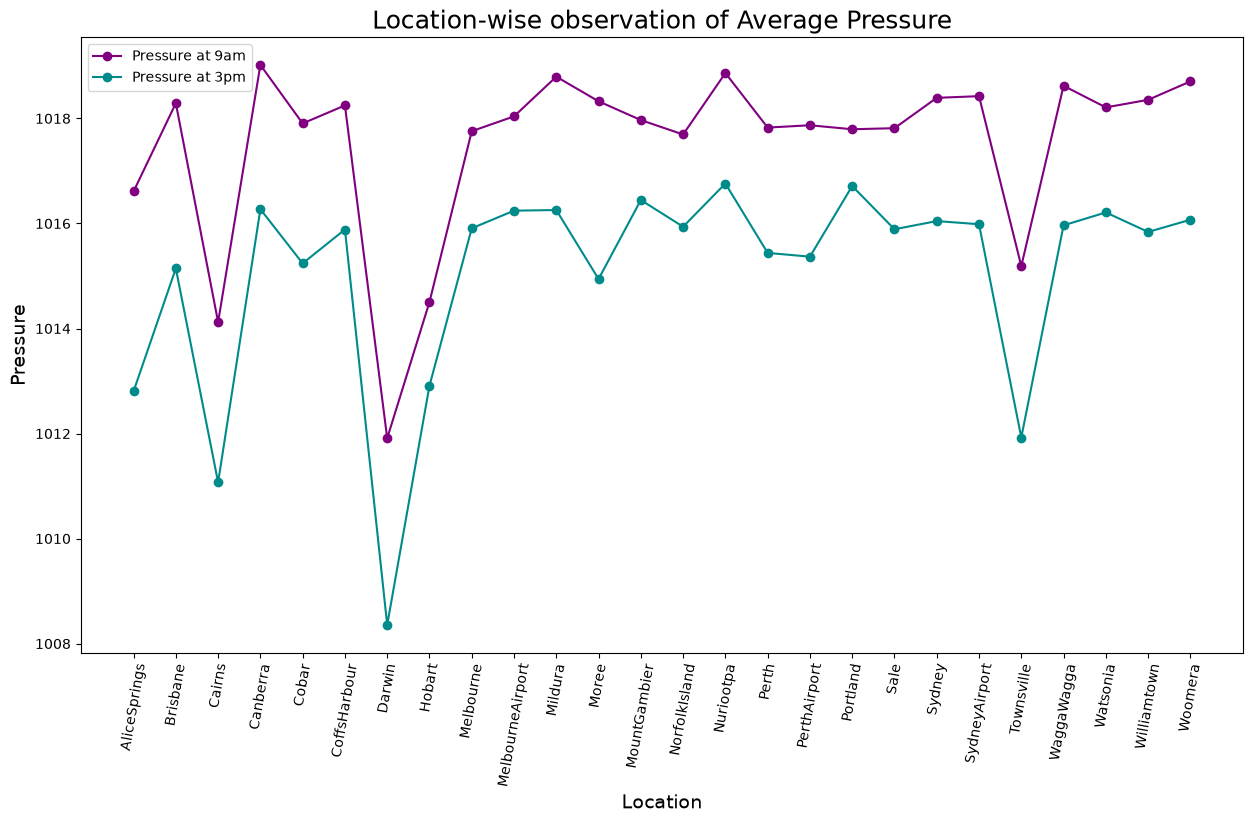

In [21]:
x = df_pressure.loc[:, 'Location']
y1 = df_pressure['Pressure9am'] 
y2 = df_pressure['Pressure3pm']

plt.figure(figsize = (15, 8))

plt.plot(x, y1, marker='o', color = 'purple', label = 'Pressure at 9am') 
plt.plot(x, y2, marker='o', color = 'darkcyan', label = 'Pressure at 3pm')

plt.xlabel('Location', fontsize = 14)
plt.ylabel('Pressure', fontsize = 14)
plt.title('Location-wise observation of Average Pressure', fontsize = 18)
plt.legend(fontsize = 10, loc = 'best')
plt.xticks(rotation=80)
plt.show()

### 4.4 Average Cloud-Obscured Portion of the Sky Analysis

In [22]:
df_cloud = df_weather_imputed.groupby(['Location'])[['Cloud9am', 'Cloud3pm']].mean()
df_cloud = df_cloud.reset_index()
df_cloud.head()

,Location,Cloud9am,Cloud3pm
0,AliceSprings,2.867129,3.273656
1,Brisbane,3.917310,3.870059
2,Cairns,4.577157,4.430973
3,Canberra,4.887333,4.849426
4,Cobar,3.298312,3.845416


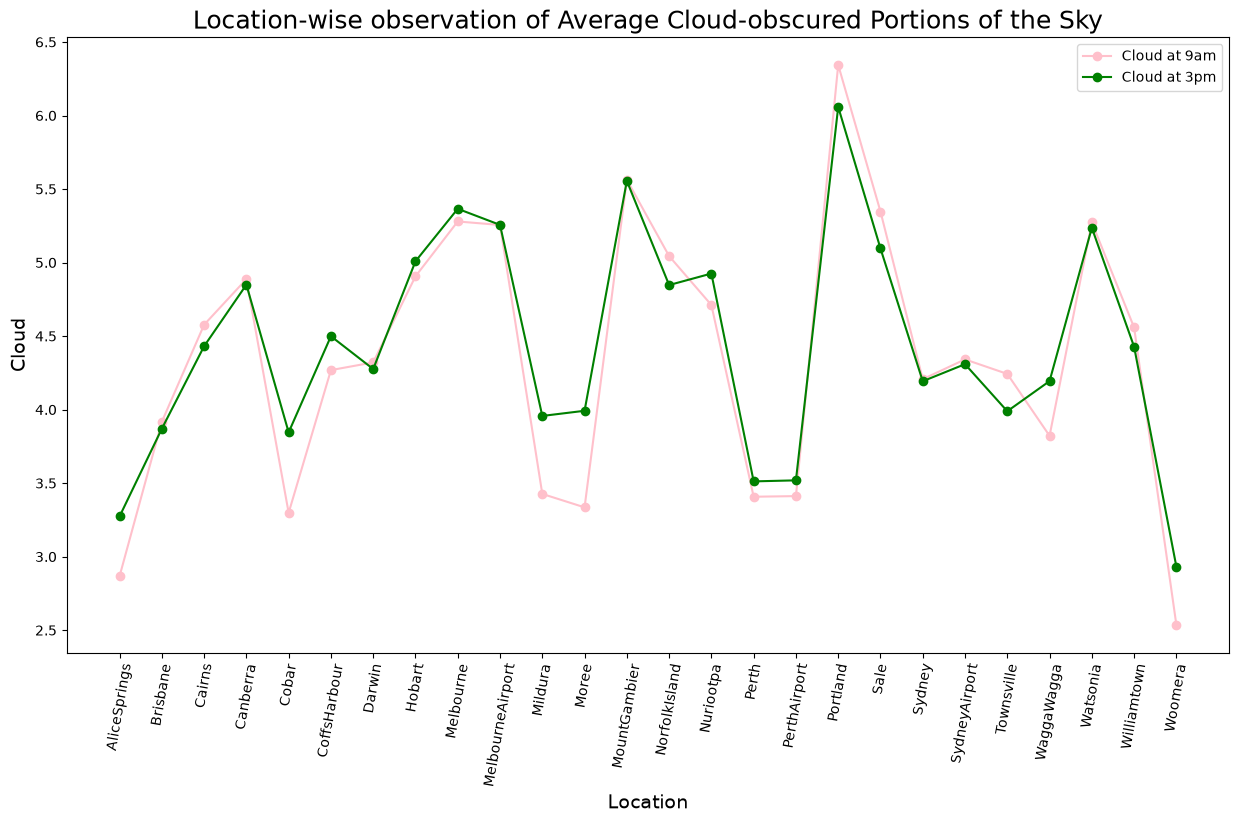

In [23]:
x = df_cloud.loc[:, 'Location']
y1 = df_cloud['Cloud9am'] 
y2 = df_cloud['Cloud3pm']

plt.figure(figsize = (15, 8))

plt.plot(x, y1, marker='o', color = 'pink', label = 'Cloud at 9am') 
plt.plot(x, y2, marker='o', color = 'green', label = 'Cloud at 3pm')

plt.xlabel('Location', fontsize = 14)
plt.ylabel('Cloud', fontsize = 14)
plt.title('Location-wise observation of Average Cloud-obscured Portions of the Sky', fontsize = 18)
plt.legend(fontsize = 10, loc = 'best')
plt.xticks(rotation=80)
plt.show()

### 4.5 Average Temperature Analysis

In [24]:
df_temperature = df_weather_imputed.groupby(['Location'])[['MinTemp', 'MaxTemp', 'Temp9am', 'Temp3pm']].mean()
df_temperature = df_temperature.reset_index()
df_temperature.head()

,Location,MinTemp,MaxTemp,Temp9am,Temp3pm
0,AliceSprings,13.219641,29.295517,21.379000,28.058263
1,Brisbane,16.374989,26.411874,21.802363,24.725114
2,Cairns,21.176868,29.532889,25.777535,27.880485
3,Canberra,6.790928,20.999749,12.663770,19.482991
4,Cobar,13.250743,25.993445,18.218321,24.671319


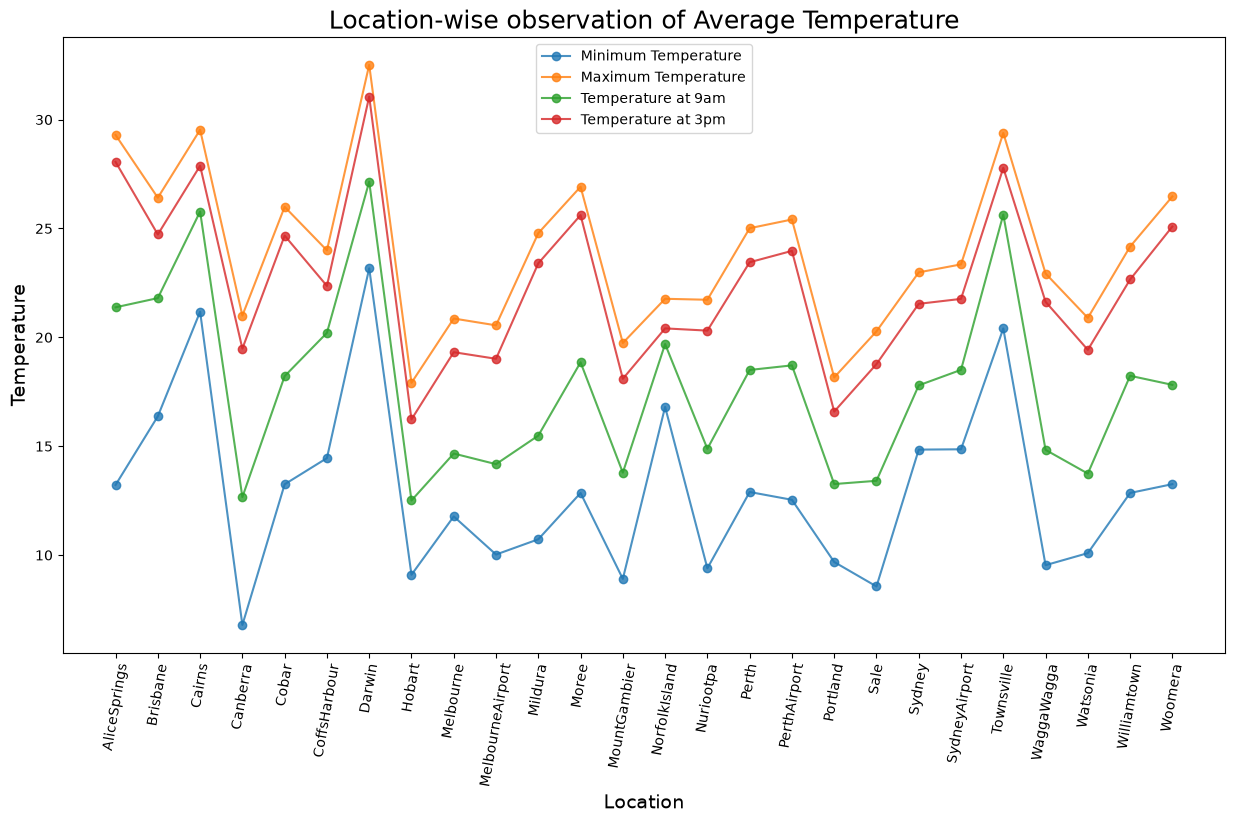

In [25]:
x = df_temperature.loc[:, 'Location']
y1 = df_temperature['MinTemp'] 
y2 = df_temperature['MaxTemp']
y3 = df_temperature['Temp9am'] 
y4 = df_temperature['Temp3pm']

plt.figure(figsize = (15, 8))

plt.plot(x, y1, label = 'Minimum Temperature', marker='o', alpha = 0.8) 
plt.plot(x, y2, label = 'Maximum Temperature', marker='o', alpha = 0.8) 
plt.plot(x, y3, label = 'Temperature at 9am', marker='o', alpha = 0.8) 
plt.plot(x, y4, label = 'Temperature at 3pm', marker='o', alpha = 0.8)

plt.xlabel('Location', fontsize = 14)
plt.ylabel('Temperature', fontsize = 14)
plt.title('Location-wise observation of Average Temperature', fontsize = 18)
plt.legend(fontsize = 10, loc = 'best')
plt.xticks(rotation=80)
plt.show()

## 5. Aggregate and join data

Aggregate

In [21]:
df_weather_imputed_2.tail()

,row ID,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
58944,Row99657,Darwin,21.9,33.0,0.0,5.2,10.9,E,44.0,SE,...,43.0,28.0,1014.6,1010.6,1.0,1.0,25.1,32.7,No,0
58945,Row99658,Darwin,19.3,33.4,0.0,6.0,11.0,ENE,35.0,SE,...,63.0,32.0,1013.9,1010.5,0.0,1.0,24.5,32.3,No,0
58946,Row99659,Darwin,21.2,32.6,0.0,7.6,8.6,E,37.0,SE,...,56.0,28.0,1014.6,1011.2,7.0,0.0,24.8,32.0,No,0
58947,Row99660,Darwin,20.7,32.8,0.0,5.6,11.0,E,33.0,E,...,46.0,23.0,1015.3,1011.8,0.0,0.0,24.8,32.1,No,0
58948,Row99661,Darwin,20.2,31.7,0.0,5.6,10.7,ENE,30.0,ENE,...,73.0,32.0,1013.9,1009.7,6.0,5.0,25.4,31.0,No,0


In [20]:
df_weather_imputed.to_csv('df_weather_imputed.csv', index=False)

In [22]:
def build_aggregated_features(df_weather, list_feat_cols, str_city_col='Location'):
    agg_funcs = ["mean", "min", "max"]
    df_weather_grp = df_weather.groupby(str_city_col)[list_feat_cols].agg(agg_funcs)

    # Flatten multi-level columns: ('MinTemp', 'mean') -> 'MinTemp_mean'
    df_weather_grp.columns = [f"{col}_{stat}" for col, stat in df_weather_grp.columns]
    df_weather_grp = df_weather_grp.reset_index()

    return df_weather_grp

In [23]:
df_weather_agg = build_aggregated_features(df_weather_imputed_2, list_col_numerical)

In [24]:
df_weather_agg.columns

Index(['Location', 'MinTemp_mean', 'MinTemp_min', 'MinTemp_max',
       'MaxTemp_mean', 'MaxTemp_min', 'MaxTemp_max', 'Rainfall_mean',
       'Rainfall_min', 'Rainfall_max', 'Evaporation_mean', 'Evaporation_min',
       'Evaporation_max', 'Sunshine_mean', 'Sunshine_min', 'Sunshine_max',
       'WindGustSpeed_mean', 'WindGustSpeed_min', 'WindGustSpeed_max',
       'WindSpeed9am_mean', 'WindSpeed9am_min', 'WindSpeed9am_max',
       'WindSpeed3pm_mean', 'WindSpeed3pm_min', 'WindSpeed3pm_max',
       'Humidity9am_mean', 'Humidity9am_min', 'Humidity9am_max',
       'Humidity3pm_mean', 'Humidity3pm_min', 'Humidity3pm_max',
       'Pressure9am_mean', 'Pressure9am_min', 'Pressure9am_max',
       'Pressure3pm_mean', 'Pressure3pm_min', 'Pressure3pm_max',
       'Cloud9am_mean', 'Cloud9am_min', 'Cloud9am_max', 'Cloud3pm_mean',
       'Cloud3pm_min', 'Cloud3pm_max', 'Temp9am_mean', 'Temp9am_min',
       'Temp9am_max', 'Temp3pm_mean', 'Temp3pm_min', 'Temp3pm_max'],
      dtype='str')

In [23]:
df_weather_agg.to_csv('df_weather_agg.csv', index=False)

Join with solar data

In [25]:
def join_with_solar(df_weather, str_solar_csv_path, str_city_col='Location'):
    """Join aggregated weather features to the per-city solar output table."""
    df_solar = pd.read_csv(str_solar_csv_path)

    df_solar = df_solar[["city", "solar_output"]].rename(columns={"city": str_city_col})
    df_solar[str_city_col] = df_solar[str_city_col].replace(r'\s+', '', regex=True)
#     print(df_solar[str_city_col].head(10))
    
    df_merged = df_weather.merge(df_solar, on=str_city_col, how="inner")

    n_weather_cities = df_weather[str_city_col].nunique()
    n_merged_cities = df_merged[str_city_col].nunique()
    if n_merged_cities < n_weather_cities:
        set_dropped_cities = set(df_weather[str_city_col].unique()) - set(df_merged[str_city_col].unique())
        print(f"\nNote: {n_weather_cities - n_merged_cities} weather-dataset cities had no "
              f"matching solar value and were dropped: {set_dropped_cities}")
        print("Check for name mismatches between the weather CSV's city names and the "
              "'city' column in city_solar_output.csv (e.g. 'MelbourneAirport' vs 'Melbourne').")

    return df_merged

In [26]:
df_merged = join_with_solar(df_weather_agg, '../output/city_solar_output.csv')

In [ ]:
df_merged.to_csv('df_merged.csv', index=False)

: 

## 6. Feature selection: check correlation of features

In [27]:
list_feat_cols = [
    f'{col}_{agg_func}'
    for col in list_col_numerical
    for agg_func in ['mean', 'min', 'max']
]
df_corr = df_merged.drop(columns=['Location']).corr()

In [28]:
df_corr_target = abs(df_corr['solar_output'])

df_relevant_train_feat = df_corr_target[df_corr_target > 0.20]
list_relevant_train_feat = list(df_relevant_train_feat.index)

In [29]:
set(df_merged.columns) - set(list_relevant_train_feat)

{'Cloud3pm_min',
 'Cloud9am_max',
 'Cloud9am_min',
 'Evaporation_min',
 'Location',
 'MaxTemp_max',
 'MinTemp_min',
 'Pressure9am_mean',
 'Rainfall_max',
 'Rainfall_mean',
 'Rainfall_min',
 'Sunshine_min',
 'Temp3pm_max',
 'WindGustSpeed_max',
 'WindGustSpeed_min',
 'WindSpeed9am_mean',
 'WindSpeed9am_min'}

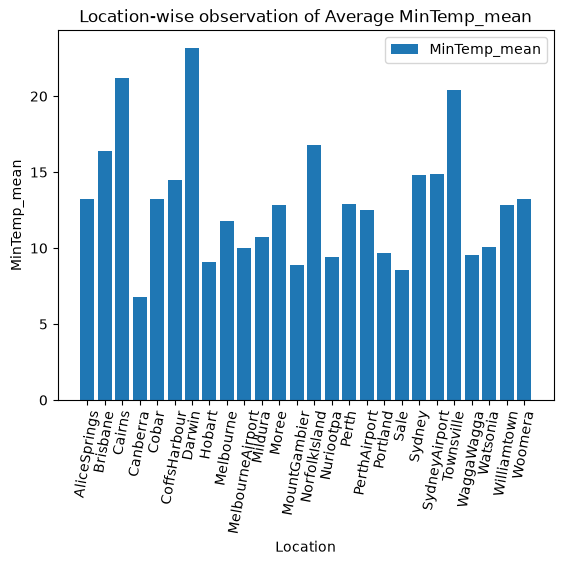

In [79]:
plot_feature(df_merged, 'MinTemp_mean')

In [31]:
len(list_relevant_train_feat)

33

In [78]:
len(list_relevant_train_feat)

34

In [82]:
df_relevant_train_feat.to_csv('view.csv')